<a href="https://colab.research.google.com/github/sinhamahi2109/ML_journey/blob/main/movie_explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("My name is Mahi Sinha")

My name is Mahi Sinha


In [2]:
import pandas as pd
url="https://raw.githubusercontent.com/dsrscientist/dataset1/master/imdb_5000_movies.csv"
df=pd.read_csv(url)
df.shape()
df.head()


HTTPError: HTTP Error 404: Not Found

In [4]:
import pandas as pd
df=pd.read_csv('movie_metadata.csv')
print(df.shape)
df.head()

(5043, 28)


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [7]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())

['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']
color                         object
director_name                 object
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_2_name                  object
actor_1_facebook_likes       float64
gross                        float64
genres                        object
actor_1_name                  object
movie_title                   object
num_voted_users                int64
cast_total_faceb

In [11]:
df=df[['movie_title', 'title_year', 'imdb_score', 'gross',
         'budget', 'genres', 'director_name', 'duration']]
df=df.dropna(subset=[ 'movie_title','title_year'])
df['title_year']=df['title_year'].astype(int)
df['movie_title']=df['movie_title'].str.strip()
print(f"Claen Dataset= {len(df)} movies")
df.head()

Claen Dataset= 4935 movies


,movie_title,title_year,imdb_score,gross,budget,genres,director_name,duration
0,Avatar,2009,7.9,760505847.0,237000000.0,Action|Adventure|Fantasy|Sci-Fi,James Cameron,178.0
1,Pirates of the Caribbean: At World's End,2007,7.1,309404152.0,300000000.0,Action|Adventure|Fantasy,Gore Verbinski,169.0
2,Spectre,2015,6.8,200074175.0,245000000.0,Action|Adventure|Thriller,Sam Mendes,148.0
3,The Dark Knight Rises,2012,8.5,448130642.0,250000000.0,Action|Thriller,Christopher Nolan,164.0
5,John Carter,2012,6.6,73058679.0,263700000.0,Action|Adventure|Sci-Fi,Andrew Stanton,132.0


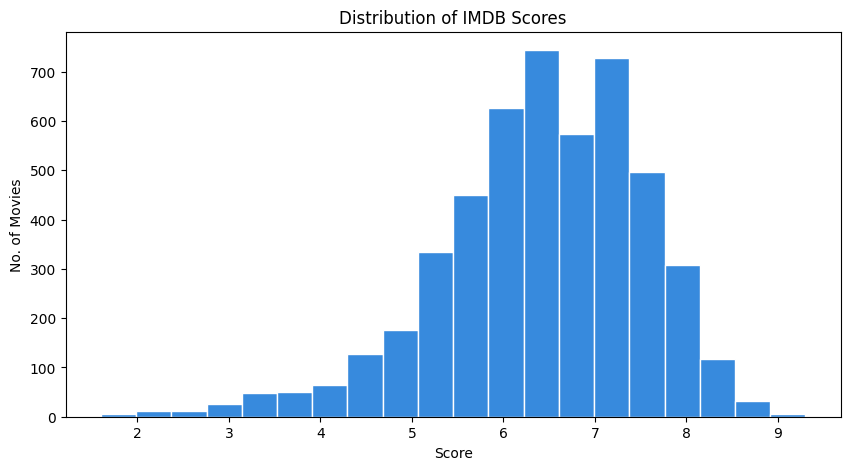

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(df['imdb_score'], bins=20, color='#378ADD', edgecolor='white')
plt.title("Distribution of IMDB Scores")
plt.xlabel("Score")
plt.ylabel("No. of Movies")
plt.show()

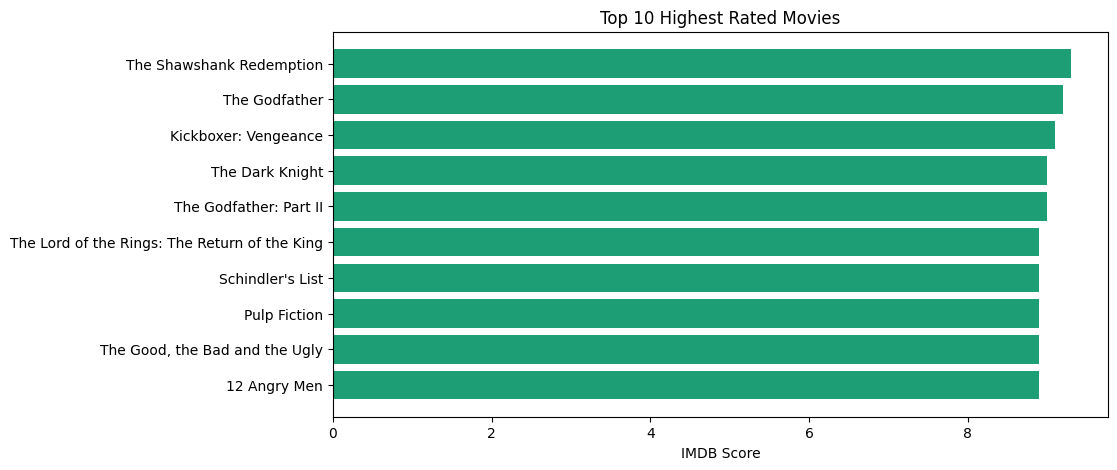

In [14]:
top10=df.nlargest(10,'imdb_score')[['movie_title','imdb_score']]
plt.figure(figsize=(10,5))
plt.barh(top10['movie_title'],top10['imdb_score'], color='#1D9E75')
plt.title('Top 10 Highest Rated Movies')
plt.xlabel('IMDB Score')
plt.gca().invert_yaxis()
plt.tight_layout
plt.show()

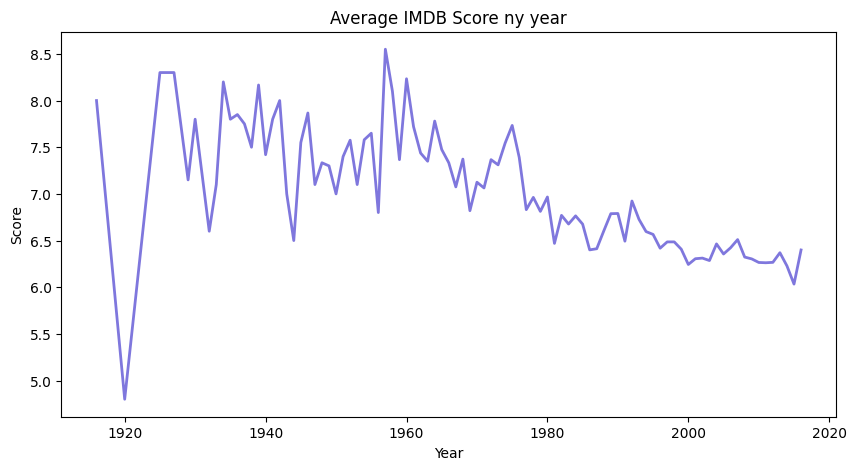

In [18]:
yearly=df.groupby('title_year')['imdb_score'].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values,color='#7F77DD',linewidth=2)
plt.title('Average IMDB Score ny year')
plt.xlabel('Year')
plt.ylabel('Score')
plt.show()

In [23]:
df['profit']=df['gross']-df['budget']
top_profit=df.nlargest(10,'profit')[['movie_title','profit']]
print(top_profit)

                                    movie_title       profit
0                                        Avatar  523505847.0
29                               Jurassic World  502177271.0
26                                      Titanic  458672302.0
3024         Star Wars: Episode IV - A New Hope  449935665.0
3080                 E.T. the Extra-Terrestrial  424449459.0
17                                 The Avengers  403279547.0
794                                The Avengers  403279547.0
509                               The Lion King  377783777.0
240   Star Wars: Episode I - The Phantom Menace  359544677.0
66                              The Dark Knight  348316061.0
